In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [2]:
file_path = "./feature_tsv/feature_table_0.8_pruning.tsv"
df = pd.read_csv(file_path, delimiter = '\t')

#### Exploratory Data Analysis 


In [3]:
df.shape

(277, 273)

In [4]:
# Examine Missing Data
df.isna().sum().sum()

0

[Text(0, 0, 'control'), Text(1, 0, 'case')]

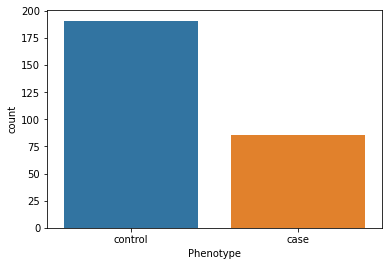

In [5]:
#Examine phenotype distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="phenotype", data=df)
plt.xlabel('Phenotype')
xtick_labels = ['control', 'case']
plt.gca().set_xticklabels(xtick_labels)

#### Correlation between continous features

![corr](./plot/correlation_continous.png)

### Gradient Boosting Decision Tree

#### Hyperparameter Tuning
Grid search is employed to identify the optimal hyperparameters for the gradient boosting model, ensuring the model is well-suited for the task. To achieve this,  a cross entropy loss is then employed  as the evaluation metric and apply 5-fold cross validation for assessing the model with the large study data. 
1. Due to the unbalanced target distribution. The default scoring (mean accuracy) will be biased towards the majority class 
2. F1 score is a harmonic mean of precision and recall, providing a balanced measure of both parameters. 
The best hyperparameters are displayed below:

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('phenotype', axis=1), df['phenotype'], test_size=0.2,  random_state=1)

In [73]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

clf = GradientBoostingClassifier(random_state=1)
param = {
    'n_estimators': [40, 50, 100, 110, 120, 130, 140, 150, 200, 250 ],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7], 
    
}

grid_search = GridSearchCV(clf, param, cv=5, n_jobs=-1, verbose=1, return_train_score=True, scoring="roc_auc")

### Evaluate Performance of the Full Model

In [74]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6,
                                           0.7],
                         'max_depth': [3, 4, 5, 6],
                         'n_estimators': [40, 50, 100, 110, 120, 130, 140, 150,
                                          200, 250]},
             return_train_score=True, scoring='roc_auc', verbose=1)

In [76]:
grid_search.best_params_

{'learning_rate': 0.7, 'max_depth': 3, 'n_estimators': 100}

In [77]:
best_model = grid_search.best_estimator_

Text(0.5, 15.0, 'Predicted')

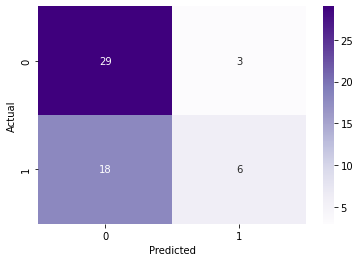

In [78]:
# confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = best_model.predict(X_test)
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt="d", cmap="Purples", xticklabels=[0,1], yticklabels=[0,1])
plt.ylabel('Actual')
plt.xlabel('Predicted')

__Prediction Distribution__

The prediction distribution and actual distribution are shown below using the entire dataset:

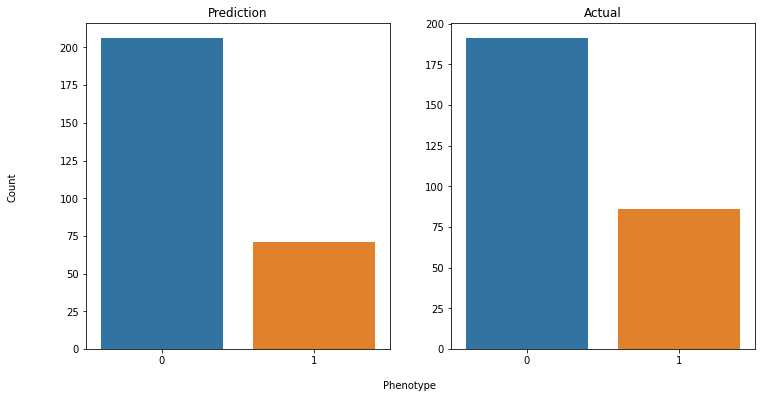

In [79]:
y_pred = best_model.predict(df.drop('phenotype', axis=1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
sns.countplot(x=y_pred, ax=ax1)
ax1.set_title('Prediction')
sns.countplot(x=df["phenotype"], ax=ax2)
ax2.set_title('Actual')
ax2.set_xlabel('')
fig.text(0.5, 0.04, 'Phenotype', ha='center', va='center')
ax2.set_ylabel('')    
ax1.set_ylabel('')
# 0.04, 0.5 are the distance from bottom and left respectively. 
fig.text(0.04, 0.5, 'Count', ha='center', va='center', rotation='vertical')

plt.show()

__Feature Importance__


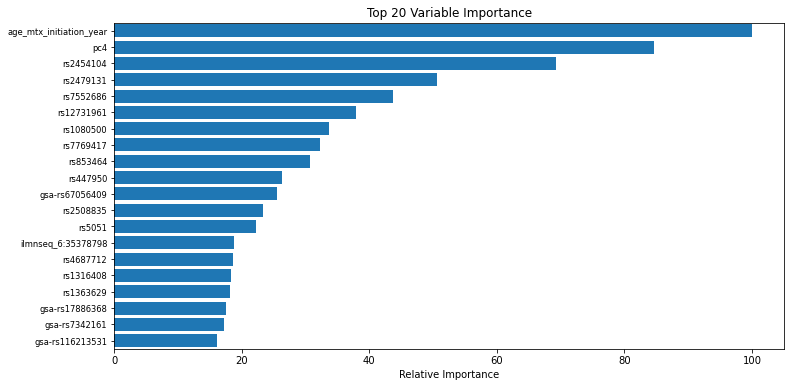

In [80]:
# feature importance
import matplotlib.pyplot as plt

feature_importance = best_model.feature_importances_
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5
plt.figure(figsize=(12, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, df.drop('phenotype', axis=1).columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.ylim(len(feature_importance)-20, len(feature_importance))
plt.title('Top 20 Variable Importance')
plt.yticks(fontsize='small')  # Change y-ticks' font size

plt.savefig("top_20_variable_importace.pdf")

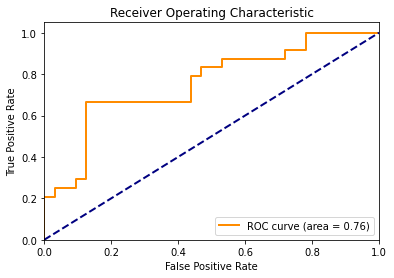

In [81]:
# ROC-AUC curve on test set to see how well the model perform on unseen data
from sklearn.metrics import roc_curve, auc, plot_roc_curve

# Predict probabilities of positive class for each instance
positive_prob = best_model.predict_proba(X_test)[:,1]

# Caluclate the ROC curve
fpr, tpr, _ =roc_curve(y_test, positive_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

* Evaluation Metrics of the model


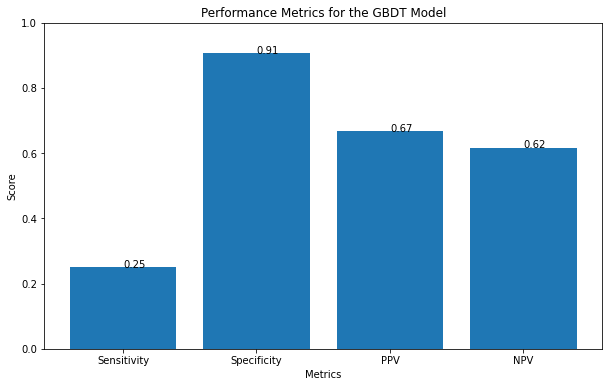

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


y_pred = best_model.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# sensitivity aka recall
sensitivity = recall

# specificity
tn, fp, fn, tp = conf.ravel() 
specificity  = tn/(tn+fp)

#ppv 
ppv = tp/(tp+fp)
#npv
npv = tn/(tn+fn)

metrics = [sensitivity, specificity, ppv, npv]
metric_names = ['Sensitivity', 'Specificity', 'PPV', 'NPV']

plt.figure(figsize=(10,6))
plt.bar(metric_names, metrics)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim([0, 1])
plt.title('Performance Metrics for the GBDT Model')
for index, value in enumerate(metrics):
    plt.text(index, value, str(round(value, 2)))
plt.savefig("GBDT_performance.pdf")


Ablation Study

In [98]:
def fit_and_evaluate(X_training_set, X_test_set, name):

    grid_search.fit(X_training_set, y_train)
    best_model = grid_search.best_estimator_
    # Predict probabilities of positive class for each instance
    positive_prob = best_model.predict_proba(X_test_set)[:,1]

    # Caluclate the ROC curve
    fpr, tpr, _ =roc_curve(y_test, positive_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label= 'ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    plt.savefig(f"ROC_AUC_for_{name}.pdf")
    
    feature_importance = best_model.feature_importances_
    feature_importance = 100.0 * (feature_importance / feature_importance.max())
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + .5
    plt.figure(figsize=(12, 6))
    plt.barh(pos, feature_importance[sorted_idx], align='center')
    plt.yticks(pos, df.drop('phenotype', axis=1).columns[sorted_idx])
    plt.xlabel('Relative Importance')
    plt.ylim(len(feature_importance)-20, len(feature_importance))
    plt.title('Top 20 Variable Importance')
    plt.yticks(fontsize='small')   

    plt.savefig(f"top_20_variable_importace_{name}.pdf")
    return best_model

* Without Genetic variants

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


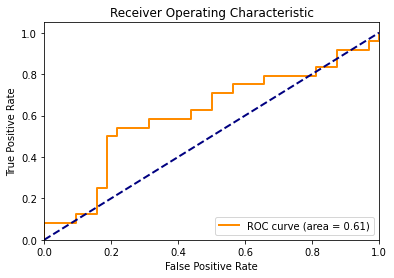

GradientBoostingClassifier(learning_rate=0.5, max_depth=6, n_estimators=110,
                           random_state=1)

<Figure size 432x288 with 0 Axes>

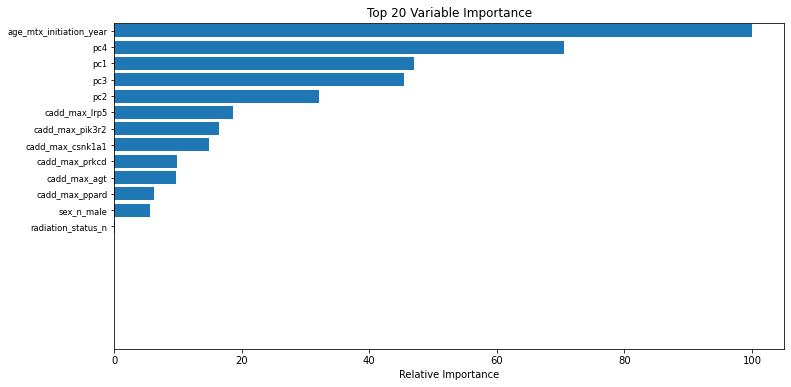

In [99]:
X_train_novariants= X_train.iloc[:,0:13]
X_test_novariants = X_test.iloc[:,0:13]
fit_and_evaluate(X_train_novariants, X_test_novariants, "novariants")


* No PCs

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


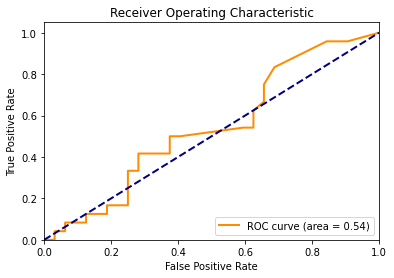

GradientBoostingClassifier(learning_rate=0.01, n_estimators=50, random_state=1)

<Figure size 432x288 with 0 Axes>

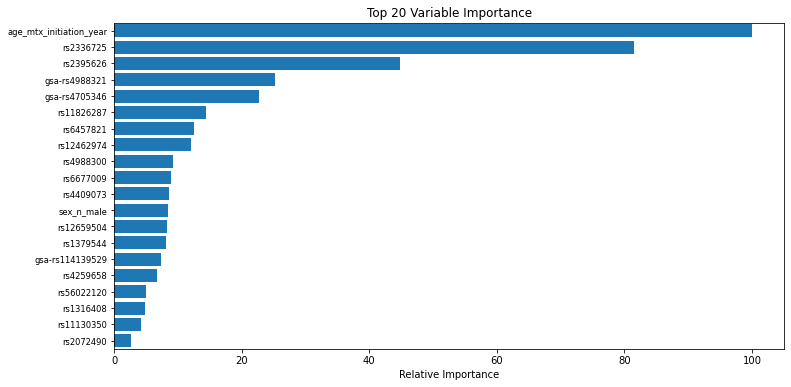

In [100]:
X_train_nopcs = X_train.drop(["pc1","pc2","pc3","pc4"], axis=1)
X_test_nopcs = X_test.drop(["pc1","pc2","pc3","pc4"], axis=1)
fit_and_evaluate(X_train_nopcs,X_test_nopcs, "nopcs" )